# Generating embeddings using TorchGeo

## 1. Dataset organization

### Downloading the CropHarvest dataset

In [1]:
from torchgeo.datasets import CropHarvest

RANDOM_STATE = 1998
ROOT = "_data"
OUTPUT_FOLDER = "_results/"
WEIGHTS = 'dofa_base_patch16_224'

original_dataset = CropHarvest(root=ROOT, download=False)

In [2]:
# pandas dataframe containing label data for everything on CropHarvest
original_dataset._load_labels(ROOT).head(5)

,type,properties.harvest_date,properties.planting_date,properties.label,properties.classification_label,properties.index,properties.is_crop,properties.lat,properties.lon,properties.dataset,properties.collection_date,properties.export_end_date,properties.externally_contributed_dataset,properties.is_test,geometry.type,geometry.coordinates,geometry
0,Feature,None,None,None,None,0,1,10.712596,37.083128,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0825205254332, 10.712735028397], [37.083...",NaN
1,Feature,None,None,None,None,1,1,10.724197,37.087377,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0872134731101, 10.7239755790256], [37.08...",NaN
2,Feature,None,None,None,None,2,1,10.713894,37.085091,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0849835772546, 10.7137105808623], [37.08...",NaN
3,Feature,None,None,None,None,3,1,10.713338,37.090290,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0902073888884, 10.7132048338664], [37.09...",NaN
4,Feature,None,None,None,None,4,1,10.721858,37.083121,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0830703114103, 10.7215953100434], [37.08...",NaN


### Exploring the dataset

In [3]:
# under properties.dataset we can find the names of the "sub datasets" inside CropHarvest
original_dataset_counts = original_dataset.labels['properties.dataset'].value_counts()

#  all the subdataset inside the CropHarvest dataset and the number of its samples
print("Sub-datasets inside CropHarvest:")
print(original_dataset_counts)

Sub-datasets inside CropHarvest:
properties.dataset
geowiki-landcover-2017          35866
croplands                       14976
canada                           9088
ile-de-france                    6184
central-asia                     5302
rwanda-ceo                       3600
reunion-france                   2776
kenya-non-crop                   2704
germany                          2550
martinique-france                2421
tanzania-ceo                     2400
mali-helmets-labelling-crops     1506
togo                             1276
lem-brazil                        860
ethiopia                          830
tanzania-rice-ecaas               800
sudan                             422
tanzania                          392
kenya                             319
togo-eval                         306
uganda                            233
mali                              148
mali-non-crop                     142
zimbabwe                           49
brazil-non-crop                    3

In [4]:
# group by the sub dataset name and look at the 'properties.label' column, which contains the crop type names
# if it is binary it will be None
# if it is multiclass it will have the crop type names

original_dataset_class_search = original_dataset.labels.groupby('properties.dataset')['properties.label'].unique()

binary = []
multiclass = []

for sub_dataset, labels in original_dataset_class_search.items():
    labels = [l for l in labels if l is not None and not (isinstance(l, float))]

    if len(labels) > 0:
        multiclass.append((sub_dataset, labels))
    else:
        binary.append(sub_dataset)

print("Binary sub-datasets:")
for i in binary:
    print(i)

print("\nMulticlass sub-datasets:")
for j in multiclass:
    print(j)

Binary sub-datasets:
brazil-non-crop
ethiopia
geowiki-landcover-2017
kenya-non-crop
mali-non-crop
rwanda-ceo
sudan
tanzania-ceo
togo
togo-eval

Multiclass sub-datasets:
('canada', ['wetland', 'abandoned (overgrown)', 'urban', 'shrubland', 'mixed forage', 'pasture (undiff)', 'sod', 'cereals (undiff)', 'barley (undiff)', 'corn', 'timothy', 'alfalfa', 'spring wheat', 'soybeans', 'forest', 'nursery', 'winter barley', 'canola/rapeseed', 'winter wheat', 'unimproved pasture', 'christmas trees', 'greenhouse', 'winter rye', 'pasture/forage', 'red clover', 'abandoned (shrubs)', 'other', 'fallow', 'native grassland', 'barren', 'water', 'oats', 'coniferous', 'white clover', 'broadleaf', 'clover (undiff)', 'sunflowers', 'greenfeed (mixed)', 'beans (undiff)', 'melon', 'apples', 'vegetables (undiff)', 'raspberry', 'fruits (berry & annual)', 'strawberry', 'onions', 'potatoes', 'broccoli', 'cauliflower', 'peas (undiff)', 'field peas', 'sugarbeets', 'ginseng', 'rye (undiff)', 'cherries', 'cucumber', 'to

## 2. *geowiki-landcover-2017* data exploration

### Isolate *geowiki-landcover-2017* sub dataset


We want to work with an isolated sub-set, binary, and preferably with lots of samples. For that reason it is wise to choose *geowiki-landcover-2017*
- **Sub dataset name:** *geowiki-landcover-2017*
- **Sample Count:** 35866 points
- **Format:** pixel-level time series

In [51]:
from torch.utils.data import Subset

# finding all the entries on original_dataset that has properties.dataset equal to 'geowiki-landcover-2017'
DATASET_NAME = 'geowiki-landcover-2017'
geowiki_indices = original_dataset.labels.index[original_dataset.labels['properties.dataset'] == DATASET_NAME].tolist()

# create the isolated dataset
geowiki_dataset = Subset(original_dataset, geowiki_indices)

print(f"Original dataset size: {len(original_dataset)}")
print(f"Isolated dataset size: {len(geowiki_dataset)}")
print(f"Geowiki indexes taken from the original dataset: {geowiki_indices[:20]}")

Original dataset size: 70213
Isolated dataset size: 35866
Geowiki indexes taken from the original dataset: [3694, 3695, 3696, 3697, 3698, 3699, 3700, 3701, 3702, 3703, 3704, 3705, 3706, 3707, 3708, 3709, 3710, 3711, 3712, 3713]


### Data structure

Each data point represents a single geographic location over a full calendar year. Each sample is provided as a $12 \times 18$ tensor:
- Rows (12): Represent the 12 months of the year (temporal dimension)
- Columns (18): Represent the spectral and environmental bands (feature dimension)

The data combines multiple sensors and environmental variables:

| Band Index | Feature Category | Description |
| :--- | :--- | :--- |
| **0 - 12** | **Sentinel-2 (Optical)** | Multi-spectral bands including RGB, NIR, and Red-Edge |
| **13 - 14** | **Sentinel-1 (Radar)** | VV and VH polarizations (crucial for cloud-penetrating growth monitoring) |
| **15** | **ERA5 (Temp)** | 2-meter temperature data (average monthly) |
| **16** | **ERA5 (Precip)** | Total monthly precipitation |
| **17** | **SRTM (Elevation)** | Digital Elevation Model (Static value repeated across time steps) |

In [6]:
original_dataset.all_bands

('VV',
 'VH',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'B11',
 'B12',
 'temperature_2m',
 'total_precipitation',
 'elevation',
 'slope',
 'NDVI')

In [7]:
geowiki_dataset[7].keys()

dict_keys(['array', 'label'])

In [8]:
geowiki_dataset.__getitem__(45)['array'].shape

torch.Size([12, 18])

In [9]:
geowiki_dataset.__getitem__(45)['label']

tensor(62)

### Turning *geowiki-landcover-2017* into a binary dataset

But we can see that, after a careful look that not only the dataset label are not bianry but also they don't match with the classification labels `properties.is_crop`shown in the beginning. 

In [10]:
def investigation(subset, original, geowiki_indices, num_samples, y_array=None):
    header = f"{'Idx':<5} | {'Origianl Idx':<5} |{'My tensor':<8} | {'Metadata is_crop':<10} | {'embedding':<8} | {'Status'}"
    print(header)
    print("-" * 75)

    for i in range(num_samples):
        # label from my dataset
        label_my_dataset = int(subset[i]['label'])
        
        # original label
        idx_original = geowiki_indices[i]
        is_crop_meta = int(original.labels['properties.is_crop'].iloc[idx_original])
        
        # label from embedding
        y_val = y_array[i] if y_array is not None else "N/A"
        
        if label_my_dataset == is_crop_meta:
            status = "ok"
        else:
            status = "!!!MISMATCH!!!"

        if y_array is not None and y_val != is_crop_meta:
            status = "embedding mismatching"


        print(f"{i:<5} | {idx_original:<12} |{label_my_dataset:<9} | {is_crop_meta:<16} | {y_val:<9} | {status}")
    
    return

In [11]:
investigation(geowiki_dataset, original_dataset, geowiki_indices, 20)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | N/A       | ok
1     | 3695         |1         | 1                | N/A       | ok
2     | 3696         |0         | 0                | N/A       | ok
3     | 3697         |1         | 1                | N/A       | ok
4     | 3698         |1         | 0                | N/A       | !!!MISMATCH!!!
5     | 3699         |1         | 1                | N/A       | ok
6     | 3700         |1         | 0                | N/A       | !!!MISMATCH!!!
7     | 3701         |0         | 1                | N/A       | !!!MISMATCH!!!
8     | 3702         |1         | 0                | N/A       | !!!MISMATCH!!!
9     | 3703         |1         | 0                | N/A       | !!!MISMATCH!!!
10    | 3704         |1         | 1                | N/A       | ok
11    | 3705         |14        | 1         

For this reason, we need to change the tensor label in each sample to match the metadata `properties.is_crop`.

In [12]:
import torch

class BinaryDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, original_dataset, bridge_indices):
        self.subset = subset
        self.original_labels = original_dataset.labels['properties.is_crop']
        self.bridge_indices = bridge_indices

    def __getitem__(self, index):
        sample = self.subset[index]
        
        orig_idx = self.bridge_indices[index]
        
        correct_label_value = int(self.original_labels.iloc[orig_idx])
        
        sample['label'] = torch.tensor(correct_label_value)
        return sample

    def __len__(self):
        return len(self.subset)

In [13]:
dataset = BinaryDatasetWrapper(geowiki_dataset, original_dataset, geowiki_indices)

In [14]:
investigation(dataset, original_dataset, geowiki_indices, 20)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | N/A       | ok
1     | 3695         |1         | 1                | N/A       | ok
2     | 3696         |0         | 0                | N/A       | ok
3     | 3697         |1         | 1                | N/A       | ok
4     | 3698         |0         | 0                | N/A       | ok
5     | 3699         |1         | 1                | N/A       | ok
6     | 3700         |0         | 0                | N/A       | ok
7     | 3701         |1         | 1                | N/A       | ok
8     | 3702         |0         | 0                | N/A       | ok
9     | 3703         |0         | 0                | N/A       | ok
10    | 3704         |1         | 1                | N/A       | ok
11    | 3705         |1         | 1                | N/A       | ok
12    | 3706         |0         | 0 

### Data visualization

In [15]:
sample = dataset[0]
sample['label']

tensor(0)

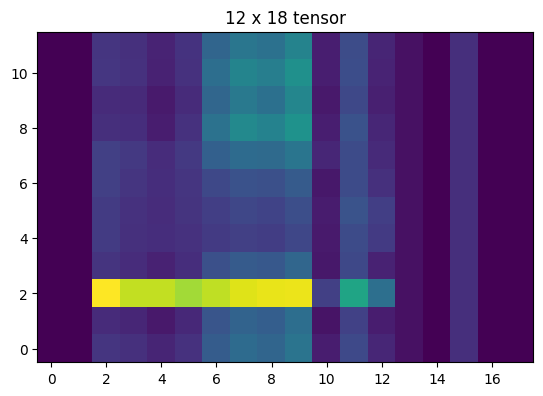

In [16]:
import matplotlib.pyplot as plt

# the actual tensor
plt.imshow(sample['array'], origin='lower')
plt.title("12 x 18 tensor")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.15533333333333332..2.3133333333333335].


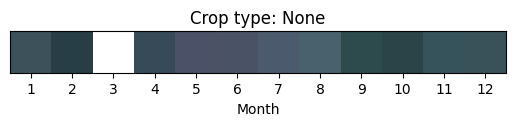

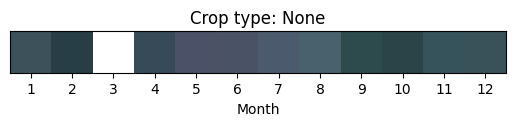

In [17]:
# it shows two plots because it is prepared to plot ground-truth and 
# it combines the rgb channels into a single pixel 
original_dataset.plot(sample)

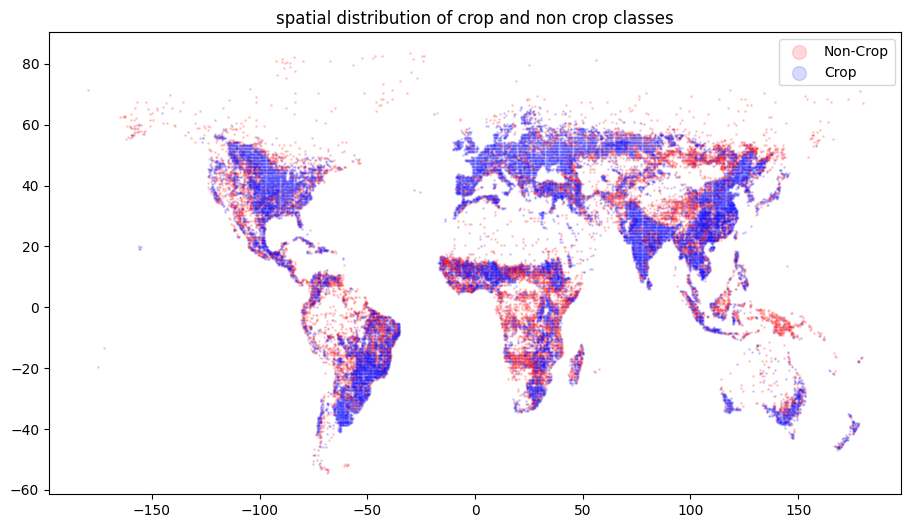

In [18]:
plt.figure(figsize=(11, 6))

geowiki_metadata = original_dataset.labels.iloc[geowiki_indices]

for is_crop, color, label in [(0, 'red', 'Non-Crop'), (1, 'blue', 'Crop')]:
    mask = geowiki_metadata['properties.is_crop'] == is_crop
    subset = geowiki_metadata[mask]
    plt.scatter(subset['properties.lon'], subset['properties.lat'], s=1, alpha=0.15, c=color, label=label)

plt.legend(markerscale=10)
plt.title("spatial distribution of crop and non crop classes")
plt.show()

## 3. Creating the embeddings model

### DOFA model

Instead of trying to retrain the whole DOFA model (which is huge and requires a lot of GPU memory), we will use DOFA as a "frozen" backbone to generate embeddings and train a simple, fast classifier on top.

In [19]:
import lightning as L
from torch.utils.data import DataLoader

class GeoWikiDataModule(L.LightningDataModule):
    def __init__(self, data, batch_size: int = 32, num_workers: int = 0):
        super().__init__()
        self.data = data
        self.batch_size = batch_size
        self.num_workers = num_workers

    def dataloader(self):
        return DataLoader(
            self.data, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers
        )

In [20]:
# loading data
data_module = GeoWikiDataModule(dataset, batch_size=32, num_workers=0)
data_loader = data_module.dataloader()

In [21]:
# define device to use, cuda, cpu or mps (our case with mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # for mac users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [22]:
from torchgeo.models import DOFABase16_Weights, get_model

model = get_model(WEIGHTS, weights=DOFABase16_Weights.DOFA_MAE)
model = model.eval()

/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We need to adapt our array (12, 18) to match the shape that DOFA model expetcs (B, C, H, W), with B = number of images per batch, C = number of channels, H = image height and W = image width. Because of the internal kernel convolutions, H and W have to be at least 16.

In our case, we don't really have images with height and width, but rather a single pixel with 18 different band observations over 12 months. The strategy applied to make our dataset meet the DOFA requirements will be:
- treat the 18 bands as channels;
- the 12 will serve as a "fake" image height;
- for the width we'll create a fake dimension, of size 1, simulating an image of (12, 1);
- for both H and W adding a lenghts, up until reaching the desired 16 size.

In [38]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def embeddings_dofa(model, dataloader, device):
    model.eval()
    model.to(device)
    x_all, y_all = [] , []
    
    # wavelengths from the bands
    wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
                   865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 490.0]

    for batch in tqdm(dataloader):
        x = batch['array'].to(torch.float32).to(device) 
        y = batch['label']

        # changes from (B, 12, 18) to (B, 18, 12)
        x = x.permute(0, 2, 1) 

        # adds a last dimension (B, 18, 12, 1)
        x = x.unsqueeze(-1)

        # last dimension adds 15
        # second last dimension adds 4
        x = F.pad(x, (0, 15, 0, 4)) # (B, 18, 12, 1) to (B, 18, 16, 16)

        with torch.inference_mode(): # dont compute gradients, just forward pa
            features = model.forward_features(x, wavelengths=wavelengths)

            if features.ndim == 3:
                embeddings = features[:, 0, :] 
            else:
                embeddings = features         

        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [24]:
# ensure that is running on mps or chosen device
model = model.to(device) 

print("Extracting embeddings...")
x, y = embeddings_dofa(model, data_loader, device)

print(f"Done! Created {x.shape[0]} vectors of size {x.shape[1]}")

Extracting embeddings...


100%|██████████| 1121/1121 [43:25<00:00,  2.32s/it]

Done! Created 35866 vectors of size 768


In [39]:
# save the embeddings
np.save(f'{OUTPUT_FOLDER}x-{DATASET_NAME}-{WEIGHTS}-normal_architecture.npy', x)
np.save(f'{OUTPUT_FOLDER}y-{DATASET_NAME}-{WEIGHTS}-normal_architecture.npy', y)

print("Files saved successfully!")

Files saved successfully!


### Sanity check

In [40]:
# load the embeddings in case you dont want to run the model again
x = np.load(f'{OUTPUT_FOLDER}x-{DATASET_NAME}-{WEIGHTS}-normal_architecture.npy')
y = np.load(f'{OUTPUT_FOLDER}y-{DATASET_NAME}-{WEIGHTS}-normal_architecture.npy')

print("Files loaded successfully!")

Files loaded successfully!


In [41]:
investigation(dataset, original_dataset, geowiki_indices, 20, y)

Idx   | Origianl Idx |My tensor | Metadata is_crop | embedding | Status
---------------------------------------------------------------------------
0     | 3694         |0         | 0                | 0         | ok
1     | 3695         |1         | 1                | 1         | ok
2     | 3696         |0         | 0                | 0         | ok
3     | 3697         |1         | 1                | 1         | ok
4     | 3698         |0         | 0                | 0         | ok
5     | 3699         |1         | 1                | 1         | ok
6     | 3700         |0         | 0                | 0         | ok
7     | 3701         |1         | 1                | 1         | ok
8     | 3702         |0         | 0                | 0         | ok
9     | 3703         |0         | 0                | 0         | ok
10    | 3704         |1         | 1                | 1         | ok
11    | 3705         |1         | 1                | 1         | ok
12    | 3706         |0         | 0 

### Extracting lat and long 

Because the metadata will be lost after the train/test split (we'll lose the original indexes), it is necessary to save, at least, the latitude and longitude, following the same index order that the *geowiki-landcover-2017* dataset has, in case we ever need to do some operation related with the dataset coordinates.

In [42]:
import pandas as pd

def extract_coords(original_dataset, geowiki_indices):
    metadata_records = []
    raw_labels_df = original_dataset.labels 
    
    for i in range(len(geowiki_indices)):
        orig_idx = geowiki_indices[i]
        
        row = raw_labels_df.iloc[orig_idx]
        
        metadata_records.append({
            'subset_index': i,
            'original_index': orig_idx,
            'lat': row['properties.lat'],
            'lon': row['properties.lon'],
            'label': int(row['properties.is_crop']) # The verified label
        })
    
    return pd.DataFrame(metadata_records)

In [43]:
df_coords = extract_coords(original_dataset, geowiki_indices)
df_coords.head(20)

,subset_index,original_index,lat,lon,label
0,0,3694,-16.547619,46.25,0
1,1,3695,-18.547619,48.25,1
2,2,3696,-21.547619,44.25,0
3,3,3697,-17.547619,45.25,1
4,4,3698,-21.547619,46.25,0
5,5,3699,-25.547619,45.25,1
6,6,3700,-17.547619,47.25,0
7,7,3701,-18.547619,47.25,1
8,8,3702,-22.547619,45.25,0
9,9,3703,-22.547619,46.25,0


## Analysing the results

### Train Test split

In [44]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

### Simple classifier

In [45]:
# verify with random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# training
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(x_train, y_train)

# predicting
y_pred = rf.predict(x_test)

# evaluating
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.552
              precision    recall  f1-score   support

           0       0.48      0.29      0.36      3153
           1       0.58      0.76      0.66      4021

    accuracy                           0.55      7174
   macro avg       0.53      0.52      0.51      7174
weighted avg       0.54      0.55      0.53      7174



### MLP as a classifier and dimention reduction

In [46]:
import torch.nn as nn

class EmbeddingProjector(nn.Module):
    def __init__(self, input_dim=728, hidden_dim=128):
        super(EmbeddingProjector, self).__init__()
        
        # 728 to 2
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  
        )
        
        self.classifier = nn.Linear(2, 1) # binary classification
        
    def forward(self, x):
        low_dim_feat = self.encoder(x)
        logits = self.classifier(low_dim_feat)
        return low_dim_feat, logits

In [47]:
from torch.utils.data import TensorDataset, DataLoader

x_MPL_train = torch.tensor(x_train, dtype=torch.float32)
y_MPL_train  = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(x_MPL_train, y_MPL_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True) 

input_features = x.shape[1] 
model = EmbeddingProjector(input_dim=input_features, hidden_dim=512) # 128 or 256 or 512
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# training loop
model.train() 
correct = 0
total = 0
total_loss = 0
for epoch in range(100):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        feat_2d, logits = model(batch_x)
        
        loss = criterion(logits, batch_y)

        preds = (logits > 0).float() 
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    acc = correct / total
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50] | Train loss: {total_loss/len(train_loader):.4f} | Train accuracy: {acc:.3f}")

Epoch [10/50] | Train loss: 0.6827 | Train accuracy: 0.559
Epoch [20/50] | Train loss: 0.6814 | Train accuracy: 0.560
Epoch [30/50] | Train loss: 0.6801 | Train accuracy: 0.561
Epoch [40/50] | Train loss: 0.6792 | Train accuracy: 0.562
Epoch [50/50] | Train loss: 0.6781 | Train accuracy: 0.563
Epoch [60/50] | Train loss: 0.6765 | Train accuracy: 0.564
Epoch [70/50] | Train loss: 0.6755 | Train accuracy: 0.565
Epoch [80/50] | Train loss: 0.6738 | Train accuracy: 0.566
Epoch [90/50] | Train loss: 0.6726 | Train accuracy: 0.567
Epoch [100/50] | Train loss: 0.6719 | Train accuracy: 0.568


In [48]:
# testing
x_MPL_test = torch.tensor(x_test, dtype=torch.float32)
y_MPL_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

test_dataset = TensorDataset(x_MPL_test, y_MPL_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def run_inference(model, loader):
    model.eval()  # set to evaluation mode
    all_coords = []
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.no_grad(): # turn off gradient computation
        for batch_x, batch_y in loader:
            feat_2d, logits = model(batch_x)
            
            preds = (logits > 0).float()
            
            correct += (preds == batch_y).sum().item()
            total += batch_y.size(0)
            
            all_coords.append(feat_2d.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(batch_y.cpu().numpy())
            
    test_acc = correct / total
    print(f"Test Accuracy: {test_acc:.3f}")
    
    return (np.concatenate(all_coords), 
            np.concatenate(all_preds), 
            np.concatenate(all_labels))

test_coords, y_pred_MLP, y_test_MLP = run_inference(model, test_loader)

Test Accuracy: 0.556


## Embeddings visualization

### Directly plotting embeddings

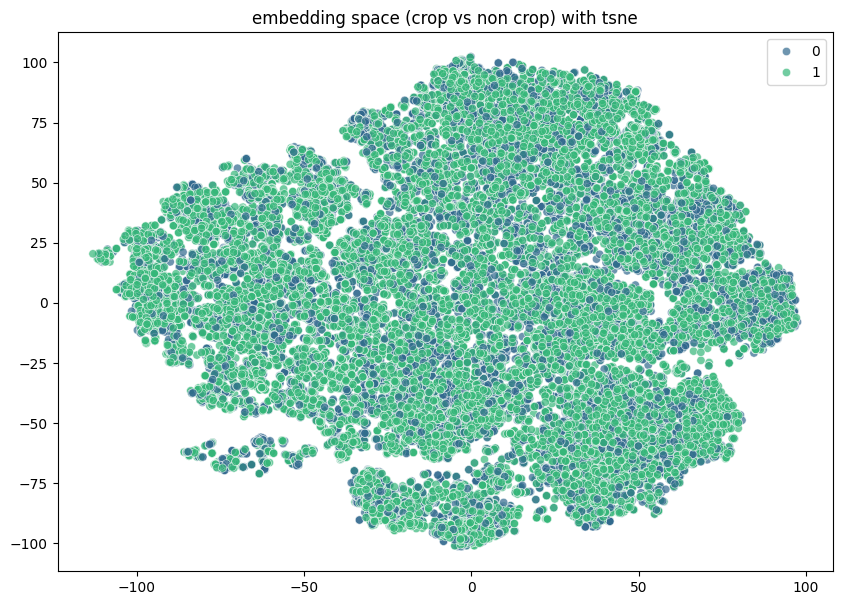

In [49]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
x_tsne = tsne.fit_transform(x) 

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_tsne[:,0], y=x_tsne[:,1], hue=y, palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop) with tsne")
plt.show()

### Plotting embeddings with MLP  dimension reduction

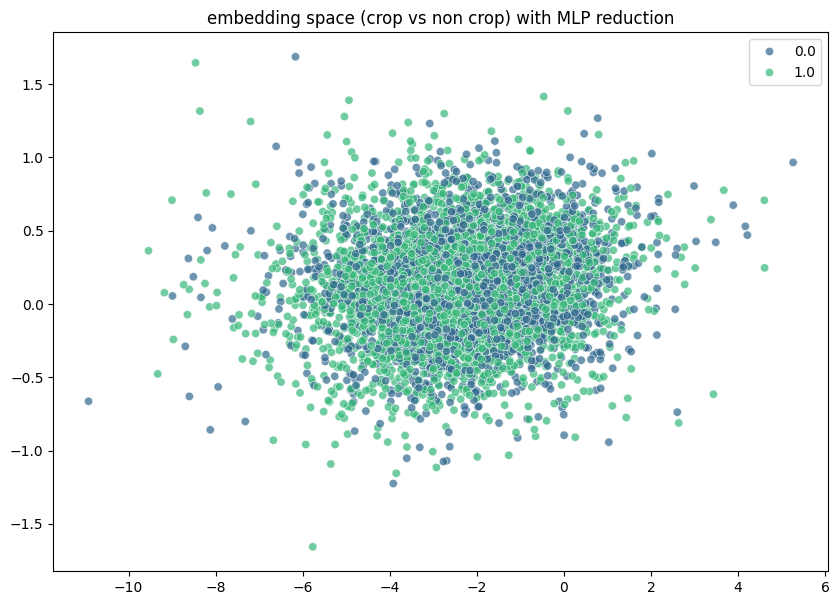

In [50]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=test_coords[:, 0], y=test_coords[:, 1], hue=y_test_MLP.flatten(), palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop) with MLP reduction")
plt.show()